# Python Code Generator + Test Case Generator
## Built with LangGraph + Groq

```
User Request
      ↓
Requirements Extractor
      ↓
Code Generator Agent  ←──────────────────┐
      ↓                                  │  retry (max 3)
Test Generator Agent                     │
      ↓                                  │
Code Executor (uses RunCode Tool)  ──[Fail]──┘
      ↓
   [Pass]
      ↓
   Response
```

## Cell 1: Imports

In [13]:
import os
import re
import sys
import subprocess
import tempfile
import textwrap
import getpass
from typing import TypedDict, Optional, Dict

from langchain_groq import ChatGroq
from langchain_core.tools import Tool
from langgraph.graph import StateGraph, END

import gradio as gr

print('All imports successful')

All imports successful


## Cell 2: API Key & LLM Setup

In [14]:
# Load from .env file if it exists, otherwise prompt
from pathlib import Path

env_file = Path('.env')
if env_file.exists():
    for line in env_file.read_text().splitlines():
        if line.startswith('GROQ_API_KEY='):
            os.environ['GROQ_API_KEY'] = line.split('=', 1)[1].strip()
            print('Loaded GROQ_API_KEY from .env file')
            break

# If still not set, ask the user
if not os.environ.get('GROQ_API_KEY'):
    os.environ['GROQ_API_KEY'] = getpass.getpass('Enter your Groq API Key: ')

# Verify connection with a quick test
try:
    llm = ChatGroq(model='llama-3.3-70b-versatile', temperature=0)
    llm.invoke('Say OK')
    print('LLM ready — connection verified')
except Exception as e:
    print(f'Connection failed: {e}')
    print('Check your GROQ_API_KEY and internet connection')

Loaded GROQ_API_KEY from .env file
LLM ready — connection verified


## Cell 3: SimpleAgent Class

Same pattern as the instructor's reference notebook. Each agent has an LLM, a list of tools, and a system prompt.
The agent:
1. Asks the LLM which tool to use
2. Extracts the right parameter for that tool
3. Calls the tool
4. Asks the LLM to generate a final response using the tool result

In [15]:
class SimpleAgent:
    """
    Simplified agent: LLM + tools + system prompt.
    Mirrors the instructor's SimpleAgent pattern.
    """
    def __init__(self, llm, tools: list, system_prompt: str, agent_name: str = 'Agent'):
        self.llm          = llm
        self.tools        = {tool.name: tool for tool in tools}
        self.system_prompt = system_prompt
        self.agent_name   = agent_name

    def invoke(self, inputs: Dict[str, str]) -> Dict[str, str]:
        query = inputs.get('input', '')

        # Step 1 — ask LLM which tool to use
        prompt = f"""{self.system_prompt}

Available Tools:
{self._format_tools()}

User Request: {query}

Think step by step:
- Which tool do you need (if any)?
- What exact input should be passed to it?"""

        response = self.llm.invoke(prompt).content

        # Step 2 — if a tool is mentioned, extract param and call it
        for tool_name, tool in self.tools.items():
            if tool_name.lower() in response.lower():
                extraction_prompt = f"""From this request:
\"{query}\"

Extract ONLY the exact input to pass to the {tool_name} tool.
Return just the value, nothing else."""
                param = self.llm.invoke(extraction_prompt).content.strip().strip('"').strip("'")
                tool_result = tool.func(param)

                # Step 3 — final answer using tool result
                final_prompt = f"""{self.system_prompt}

User Request: {query}
Tool Used: {tool_name}
Tool Result:
{tool_result}

Now provide your final response based on the tool result:"""
                return {'output': self.llm.invoke(final_prompt).content}

        # No tool needed — return direct LLM response
        return {'output': response}

    def _format_tools(self) -> str:
        if not self.tools:
            return 'No tools available — respond directly.'
        return '\n'.join(f'- {t.name}: {t.description}' for t in self.tools.values())


print('SimpleAgent class ready')

SimpleAgent class ready


## Cell 4: Tools

`run_code_tool` — executes Python code in a subprocess sandbox and returns stdout/stderr.
This is a **Tool** (not an agent), used by the Code Executor node.

In [16]:
def run_python_code(code: str) -> str:
    """
    Executes Python code in a subprocess sandbox.
    Returns combined stdout + stderr.
    """
    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
        f.write(code)
        tmp_path = f.name
    try:
        result = subprocess.run(
            [sys.executable, tmp_path],
            capture_output=True, text=True, timeout=15
        )
        return (result.stdout + result.stderr).strip(), result.returncode
    except subprocess.TimeoutExpired:
        return 'Error: Code execution timed out (15s limit)', 1


# Wrap as a LangChain Tool
run_code_tool = Tool(
    name='RunCode',
    func=lambda code: run_python_code(code)[0],   # tool only needs the string output
    description='Executes Python code in a sandbox and returns stdout/stderr. '
                'Input must be complete, runnable Python code.'
)

print('RunCode tool ready')

RunCode tool ready


## Cell 5: Agents

Two **SimpleAgent** instances — one for code generation, one for test generation.

In [17]:
# ── Agent 1: Code Generator ───────────────────────────────────────────────────
code_generator_agent = SimpleAgent(
    llm=llm,
    tools=[],          # pure LLM generation, no tools needed
    system_prompt="""You are an expert Python developer. Your ONLY job is to write correct, clean Python code.

When given requirements:
1. Read the requirements carefully, including any edge cases
2. Write clean, Pythonic code with no placeholder comments
3. Handle all edge cases mentioned
4. Return ONLY a ```python ... ``` code block — no explanation

If you receive a previous error, analyse it and fix the root cause.""",
    agent_name='Code Generator Agent'
)

# ── Agent 2: Test Generator ───────────────────────────────────────────────────
test_generator_agent = SimpleAgent(
    llm=llm,
    tools=[],          # pure LLM generation
    system_prompt="""You are a Python testing expert. Your ONLY job is to write pytest-style test cases.

When given code to test:
1. Write 4-6 test functions, each named test_*
2. Cover: happy path, edge cases, boundary values, error cases
3. Use plain assert statements
4. Do NOT import the code under test — it will be injected above your tests automatically
5. Return ONLY a ```python ... ``` code block — no explanation""",
    agent_name='Test Generator Agent'
)

print('Code Generator Agent ready')
print('Test Generator Agent ready')

Code Generator Agent ready
Test Generator Agent ready


## Cell 6: LangGraph State

In [18]:
class CodeGenState(TypedDict):
    user_request:      str    # original natural-language description
    requirements:      str    # structured spec from requirements extractor
    generated_code:    str    # code produced by code generator agent
    test_code:         str    # tests produced by test generator agent
    execution_result:  str    # stdout/stderr from RunCode tool
    execution_success: bool   # True if all tests passed
    retry_count:       int    # incremented by executor on failure
    error_message:     str    # last error, fed back to code generator agent
    final_response:    str    # formatted answer shown to user

MAX_RETRIES = 3

def extract_code(text: str) -> str:
    """Strip markdown code fences from LLM output."""
    match = re.search(r'```(?:python)?\n(.*?)```', text, re.DOTALL)
    return match.group(1).strip() if match else text.strip()

print('State schema defined')

State schema defined


## Cell 7: Graph Nodes

Each node is a thin wrapper that calls the right agent/tool and updates state.

| Node | Calls | Role |
|---|---|---|
| `requirements_extractor` | LLM directly | Extracts structured spec |
| `code_generator_node` | `code_generator_agent` | Generates / refines Python code |
| `test_generator_node` | `test_generator_agent` | Generates pytest test cases |
| `code_executor_node` | `run_code_tool` | Runs code + tests, updates retry_count |
| `response_node` | — | Formats final output |

In [ ]:
MAX_RETRIES = 3

def extract_code(text: str) -> str:
    """Strip markdown code fences from LLM output."""
    match = re.search(r'```(?:python)?\n(.*?)```', text, re.DOTALL)
    return match.group(1).strip() if match else text.strip()


def parse_test_report(execution_result: str) -> str:
    """Parse executor output into a clean pass/fail table."""
    lines  = execution_result.splitlines()
    passed = [l.strip() for l in lines if l.strip().startswith('PASS')]
    failed = [l.strip() for l in lines if l.strip().startswith('FAIL')]
    total  = len(passed) + len(failed)

    rows = ''
    for p in passed:
        name = p.replace('PASS', '').strip()
        rows += f'| {name} | ✅ PASS |\n'
    for f in failed:
        name = f.split(':')[0].replace('FAIL', '').strip()
        detail = f.split(':', 1)[1].strip() if ':' in f else ''
        rows += f'| {name} | ❌ FAIL — {detail} |\n'

    summary = f'**{len(passed)}/{total} tests passed**'
    table = f'| Test Function | Result |\n|---|---|\n{rows}'
    return f'{table}\n{summary}'


# ── Node 1: Requirements Extractor ───────────────────────────────────────────
def requirements_extractor_node(state: CodeGenState) -> dict:
    print('[REQUIREMENTS] Extracting structured spec...')
    prompt = f"""You are a software requirements analyst.
Extract a structured specification from the user request.

User request: {state['user_request']}

Return ONLY this format:
TASK_TYPE: <function | class | script>
NAME: <name>
DESCRIPTION: <one sentence>
PARAMETERS: <param: type, ... or None>
RETURNS: <return type and description>
EDGE_CASES: <comma-separated edge cases>"""

    requirements = llm.invoke(prompt).content.strip()
    print(f'[REQUIREMENTS]\n{requirements}\n')
    return {'requirements': requirements}


# ── Node 2: Code Generator (uses Code Generator Agent) ───────────────────────
def code_generator_node(state: CodeGenState) -> dict:
    print(f'[CODE GENERATOR AGENT] Generating code (retry={state.get("retry_count", 0)})...')

    agent_input = f'Requirements:\n{state["requirements"]}'
    if state.get('error_message') and state.get('retry_count', 0) > 0:
        agent_input += (
            f'\n\nPrevious attempt FAILED. Fix these errors:\n{state["error_message"]}'
            f'\n\nFailed code:\n```python\n{state["generated_code"]}\n```'
        )

    result = code_generator_agent.invoke({'input': agent_input})
    code   = extract_code(result['output'])
    print(f'[CODE GENERATOR AGENT] Done — {len(code.splitlines())} lines.')
    return {'generated_code': code, 'error_message': ''}


# ── Node 3: Test Generator (uses Test Generator Agent) ───────────────────────
def test_generator_node(state: CodeGenState) -> dict:
    print('[TEST GENERATOR AGENT] Generating test cases...')

    agent_input = (
        f'Write pytest tests for this code.\n\n'
        f'Code:\n```python\n{state["generated_code"]}\n```\n\n'
        f'Requirements (for reference):\n{state["requirements"]}'
    )

    result    = test_generator_agent.invoke({'input': agent_input})
    test_code = extract_code(result['output'])
    print(f'[TEST GENERATOR AGENT] Done — {len(test_code.splitlines())} lines.')
    return {'test_code': test_code}


# ── Node 4: Code Executor (uses RunCode Tool) ────────────────────────────────
def code_executor_node(state: CodeGenState) -> dict:
    print('[CODE EXECUTOR] Running code + tests via RunCode tool...')

    combined = textwrap.dedent(f"""
{state['generated_code']}

{state['test_code']}

# ── Auto-run all test_ functions ──
import sys as _sys
_passed = _failed = 0
for _name, _fn in list(globals().items()):
    if _name.startswith('test_') and callable(_fn):
        try:
            _fn()
            print(f'  PASS  {{_name}}')
            _passed += 1
        except Exception as _e:
            print(f'  FAIL  {{_name}}: {{_e}}')
            _failed += 1
print(f'\\nResults: {{_passed}} passed, {{_failed}} failed')
if _failed > 0:
    _sys.exit(1)
    """).strip()

    output, returncode = run_python_code(combined)
    success = returncode == 0

    print(f'[CODE EXECUTOR] Success={success}\n{output}\n')

    retry_count = state.get('retry_count', 0)
    if not success:
        retry_count += 1

    return {
        'execution_result':  output,
        'execution_success': success,
        'error_message':     '' if success else output,
        'retry_count':       retry_count,
    }


# ── Node 5: Response Formatter ────────────────────────────────────────────────
def response_node(state: CodeGenState) -> dict:
    print('[RESPONSE] Formatting final output...')
    status  = '✅ All tests passed' if state['execution_success'] else '❌ Tests did not pass'
    retries = state.get('retry_count', 0)
    report  = parse_test_report(state['execution_result'])

    response = (
        f'## 1️⃣  Source Code\n\n'
        f'```python\n{state["generated_code"]}\n```\n\n'
        f'---\n\n'
        f'## 2️⃣  Test Cases Report\n\n'
        f'{report}\n\n'
        f'{status} after {retries} retry/retries.\n\n'
        f'---\n\n'
        f'## 3️⃣  Run with Your Own Input\n\n'
        f'Switch to the **"▶ Run with Your Input"** tab, enter your argument values, '
        f'and click **Run** to verify the code yourself.'
    )
    return {'final_response': response}


print('All nodes defined')

## Cell 8: Routing (Conditional Edge)

After the executor runs:
- **Pass** → `response_node`  
- **Fail + retries left** → back to `code_generator_node` (no dummy refinement node needed)  
- **Fail + max retries** → `response_node` with error

In [20]:
def route_after_executor(state: CodeGenState) -> str:
    if state['execution_success']:
        print('[ROUTER] Tests PASSED → response')
        return 'response_node'
    if state.get('retry_count', 0) < MAX_RETRIES:
        print(f'[ROUTER] Tests FAILED (retry {state["retry_count"]}/{MAX_RETRIES}) → code_generator')
        return 'code_generator_node'
    print('[ROUTER] Max retries reached → response')
    return 'response_node'

print('Routing function ready')

Routing function ready


## Cell 9: Build & Compile the LangGraph

In [21]:
builder = StateGraph(CodeGenState)

# ── Nodes ─────────────────────────────────────────────────────────────────────
builder.add_node('requirements_extractor', requirements_extractor_node)
builder.add_node('code_generator_node',    code_generator_node)
builder.add_node('test_generator_node',    test_generator_node)
builder.add_node('code_executor_node',     code_executor_node)
builder.add_node('response_node',          response_node)

# ── Linear edges ──────────────────────────────────────────────────────────────
builder.set_entry_point('requirements_extractor')
builder.add_edge('requirements_extractor', 'code_generator_node')
builder.add_edge('code_generator_node',    'test_generator_node')
builder.add_edge('test_generator_node',    'code_executor_node')
builder.add_edge('response_node',          END)

# ── Conditional edge: executor → pass or retry loop ───────────────────────────
builder.add_conditional_edges(
    'code_executor_node',
    route_after_executor,
    {
        'response_node':       'response_node',
        'code_generator_node': 'code_generator_node',   # retry loop, no refinement node
    }
)

graph = builder.compile()
print('LangGraph compiled successfully!')

LangGraph compiled successfully!


## Cell 10: LangGraph Flow Diagram

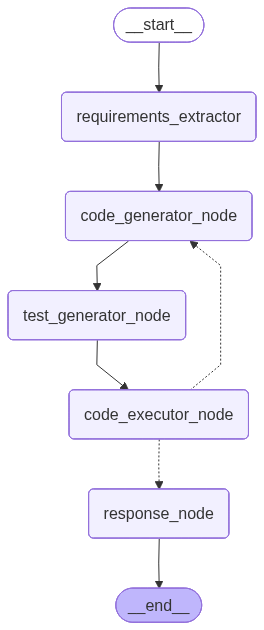

In [22]:
try:
    from IPython.display import display, Image
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

## Cell 11: Helper

In [23]:
def generate_code(user_request: str) -> dict:
    initial_state: CodeGenState = {
        'user_request':      user_request,
        'requirements':      '',
        'generated_code':    '',
        'test_code':         '',
        'execution_result':  '',
        'execution_success': False,
        'retry_count':       0,
        'error_message':     '',
        'final_response':    '',
    }
    return graph.invoke(initial_state)

print('generate_code() helper ready')

generate_code() helper ready


## Cell 12: Test Examples

In [24]:
result = generate_code('Write a function that checks if a number is prime')
print(result['final_response'])

[REQUIREMENTS] Extracting structured spec...
[REQUIREMENTS]
TASK_TYPE: function
NAME: is_prime
DESCRIPTION: Checks if a given number is prime.
PARAMETERS: number: integer
RETURNS: boolean indicating whether the number is prime
EDGE_CASES: negative numbers, zero, one, non-integer inputs

[CODE GENERATOR AGENT] Generating code (retry=0)...
[CODE GENERATOR AGENT] Done — 9 lines.
[TEST GENERATOR AGENT] Generating test cases...
[TEST GENERATOR AGENT] Done — 34 lines.
[CODE EXECUTOR] Running code + tests via RunCode tool...
[CODE EXECUTOR] Success=True
[CODE EXECUTOR]
PASS  test_is_prime_happy_path
  PASS  test_is_prime_edge_cases
  PASS  test_is_prime_boundary_values
  PASS  test_is_prime_error_cases
  PASS  test_is_prime_non_integer_inputs
  PASS  test_is_prime_composite_numbers

Results: 6 passed, 0 failed

[ROUTER] Tests PASSED → response
[RESPONSE] Formatting final output...
## Generated Code
```python
def is_prime(number: int) -> bool:
    if not isinstance(number, int):
        raise 

In [25]:
result = generate_code('Write a function that finds the two numbers in a list that add up to a target sum')
print(result['final_response'])

[REQUIREMENTS] Extracting structured spec...
[REQUIREMENTS]
TASK_TYPE: function
NAME: find_target_sum_pair
DESCRIPTION: This function finds two numbers in a list that add up to a target sum.
PARAMETERS: numbers: list, target_sum: int
RETURNS: tuple of two integers or None if no pair is found
EDGE_CASES: empty list, single element list, no pair adds up to target sum, duplicate pairs, non-integer elements, non-numeric elements

[CODE GENERATOR AGENT] Generating code (retry=0)...
[CODE GENERATOR AGENT] Done — 16 lines.
[TEST GENERATOR AGENT] Generating test cases...
[TEST GENERATOR AGENT] Done — 37 lines.
[CODE EXECUTOR] Running code + tests via RunCode tool...
[CODE EXECUTOR] Success=True
[CODE EXECUTOR]
PASS  test_happy_path
  PASS  test_empty_list
  PASS  test_single_element_list
  PASS  test_no_pair
  PASS  test_non_numeric_elements
  PASS  test_invalid_input_type

Results: 6 passed, 0 failed

[ROUTER] Tests PASSED → response
[RESPONSE] Formatting final output...
## Generated Code
```

## Cell 13: Gradio Chat UI

In [ ]:
# Global store — holds the last generated code so Tab 2 can use it
_session = {'code': '', 'function_name': '', 'requirements': ''}


def _extract_fn_name(code: str) -> str:
    m = re.search(r'^def (\w+)\(', code, re.MULTILINE)
    if m:
        return m.group(1)
    m = re.search(r'^class (\w+)', code, re.MULTILINE)
    return m.group(1) if m else ''


# ── Tab 1 callback ────────────────────────────────────────────────────────────
def gradio_generate(message: str, history: list) -> str:
    try:
        result = generate_code(message)
        _session['code']          = result['generated_code']
        _session['function_name'] = _extract_fn_name(result['generated_code'])
        _session['requirements']  = result['requirements']
        return result['final_response']
    except Exception as e:
        return f'Error: {str(e)}'


# ── Tab 2 callbacks ───────────────────────────────────────────────────────────
def refresh_code_view() -> tuple:
    code = _session.get('code', '')
    fn   = _session.get('function_name', '')
    if not code:
        return '', 'No code generated yet — go to the Generate tab first.'
    hint = f'Function detected: `{fn}(...)` — enter arguments in Python syntax below.' if fn else ''
    return code, hint


def run_with_custom_input(user_args: str) -> str:
    code = _session.get('code', '')
    fn   = _session.get('function_name', '')

    if not code:
        return 'No code generated yet. Generate code in Tab 1 first.'
    if not fn:
        return 'Could not detect a function name in the generated code.'
    if not user_args.strip():
        return 'Please enter input arguments (e.g.  7  or  [1,2,3]  or  "hello").'

    script = f"""{code}

try:
    _result = {fn}({user_args})
    print(f">>> {fn}({user_args})")
    print(f"    Output : {{_result}}")
    print(f"    Type   : {{type(_result).__name__}}")
except TypeError as e:
    print(f"Wrong arguments: {{e}}")
except Exception as e:
    print(f"Error: {{e}}")
"""
    output, _ = run_python_code(script)
    return output


# ── Gradio UI ─────────────────────────────────────────────────────────────────
with gr.Blocks(title='Python Code Generator + Test Case Generator') as demo:

    gr.Markdown('# Python Code Generator + Test Case Generator')
    gr.Markdown('*LangGraph • SimpleAgent Pattern • Groq (llama-3.3-70b)*')

    # ── Tab 1: Generate Code ──────────────────────────────────────────────────
    with gr.Tab('Generate Code'):
        gr.ChatInterface(
            fn=gradio_generate,
            examples=[
                'Write a function to check if a string is a palindrome',
                'Write a function that finds the factorial of a number recursively',
                'Write a function that merges two sorted lists into one sorted list',
                'Write a function that counts the frequency of each word in a string',
            ],
        )

    # ── Tab 2: Run with Your Input ────────────────────────────────────────────
    with gr.Tab('▶  Run with Your Input'):
        gr.Markdown(
            '### Verify the generated code with your own values\n'
            'Generate code in **Tab 1** first, then come back here to test it manually.'
        )

        refresh_btn = gr.Button('↻  Load generated code', variant='secondary')
        fn_hint     = gr.Markdown('_Click ↻ to load the latest generated code._')

        code_view = gr.Code(
            label='Generated Source Code',
            language='python',
            interactive=False,
            value='',
        )

        gr.Markdown('#### Enter your own input arguments (Python syntax)')
        gr.Markdown('Examples: `7` | `[1, 2, 3]` | `"hello"` | `[3,1,4], 5`')

        user_args = gr.Textbox(
            label='Input arguments',
            placeholder='e.g.  7   or   [1, 2, 3]   or   "hello world"',
            lines=1,
        )

        run_btn = gr.Button('▶  Run', variant='primary')

        output_box = gr.Textbox(
            label='Output',
            lines=6,
            interactive=False,
            placeholder='Output will appear here after clicking Run...',
        )

        refresh_btn.click(fn=refresh_code_view, outputs=[code_view, fn_hint])
        run_btn.click(fn=run_with_custom_input, inputs=[user_args], outputs=[output_box])


demo.launch(debug=True, share=True)